# Лабораторная работа 3

Вариант 3. Поиск книг по теме Python programming через Open Library Search и сведения об авторах из Authors API.

In [1]:
from pathlib import Path
import json
import hashlib
import pandas as pd
import matplotlib.pyplot as plt
from collect import collect

result = collect(run_label='notebook')
assert result['total_rows'] >= 300
assert result['search_pages'] >= 3

{
  "run": "notebook",
  "query": "python programming",
  "fetched": 360,
  "new_records": 0,
  "total_rows": 360,
  "search_pages": 4,
  "language_rows": 225,
  "merge_rows_before": 360,
  "merge_rows_after": 360,
  "duration_s": 7.1083,
  "requests": 4,
  "response_bytes": 79964,
  "retries": 0,
  "status_counts": {
    "200": 4
  },
  "rate_headers": {},
  "peak_memory_mib": 129.227
}


## Повторный запуск

Состояние хранит обработанные ключи книг. Повторный сбор не добавляет те же записи.

In [2]:
before = hashlib.sha256(Path('data_clean.csv').read_bytes()).hexdigest()
repeat = collect(run_label='notebook_repeat')
after = hashlib.sha256(Path('data_clean.csv').read_bytes()).hexdigest()
assert repeat['new_records'] == 0
assert before == after
repeat

{
  "run": "notebook_repeat",
  "query": "python programming",
  "fetched": 360,
  "new_records": 0,
  "total_rows": 360,
  "search_pages": 4,
  "language_rows": 225,
  "merge_rows_before": 360,
  "merge_rows_after": 360,
  "duration_s": 5.6634,
  "requests": 4,
  "response_bytes": 79964,
  "retries": 0,
  "status_counts": {
    "200": 4
  },
  "rate_headers": {},
  "peak_memory_mib": 129.762
}


{'run': 'notebook_repeat',
 'query': 'python programming',
 'fetched': 360,
 'new_records': 0,
 'total_rows': 360,
 'search_pages': 4,
 'language_rows': 225,
 'merge_rows_before': 360,
 'merge_rows_after': 360,
 'duration_s': 5.6634,
 'requests': 4,
 'response_bytes': 79964,
 'retries': 0,
 'status_counts': {'200': 4},
 'rate_headers': {},
 'peak_memory_mib': 129.762}

## Итоговая таблица и полнота

In [3]:
data = pd.read_csv('data_clean.csv')
quality = json.loads(Path('quality.json').read_text(encoding='utf-8'))
display(data.head())
display(pd.DataFrame(quality['completeness_percent'].items(), columns=['Поле', 'Полнота, %']))
assert quality['duplicates'] == 0
assert quality['required_empty_rows'] == 0

,work_id,title,first_publish_year,edition_count,author_key,author_name_catalogue,author_count,language_count,languages,collected_at,url,author_name_verified,author_revision,author_modified_at,author_url,author_matched
0,/works/OL10056472W,Bioinformatics Programming in Python,1991,4,OL4037358A,Ruediger-Marcus Flaig,1,1,eng,2026-10-07T14:33:38.799303+00:00,https://openlibrary.org/works/OL10056472W,Ruediger-Marcus Flaig,1.0,2008-04-30T20:50:18.033121+00:00,https://openlibrary.org/authors/OL4037358A,True
1,/works/OL1033722W,XML Processing with Python,2000,2,OL100618A,Sean McGrath,1,1,eng,2026-10-07T14:33:38.799303+00:00,https://openlibrary.org/works/OL1033722W,Sean McGrath,2.0,2008-09-08T16:24:07.101641+00:00,https://openlibrary.org/authors/OL100618A,True
2,/works/OL10538818W,The life of Python,1986,2,OL4374464A,George Perry,1,1,eng,2026-10-07T14:33:38.799303+00:00,https://openlibrary.org/works/OL10538818W,George Perry,1.0,2008-08-31T16:24:43.636541+00:00,https://openlibrary.org/authors/OL4374464A,True
3,/works/OL106747W,Python scripting for computational science,2004,2,OL20350A,Hans Petter Langtangen,1,1,eng,2026-10-07T14:33:38.799303+00:00,https://openlibrary.org/works/OL106747W,Hans Petter Langtangen,2.0,2008-09-11T08:24:11.737778+00:00,https://openlibrary.org/authors/OL20350A,True
4,/works/OL11791152W,Python for bioinformatics,2009,1,OL5024556A,Jason M. Kinser,1,1,eng,2026-10-07T14:33:38.799303+00:00,https://openlibrary.org/works/OL11791152W,Jason M. Kinser,1.0,2008-09-24T01:30:22.312848+00:00,https://openlibrary.org/authors/OL5024556A,True


,Поле,"Полнота, %"
0,work_id,100.00
1,title,100.00
2,first_publish_year,100.00
3,edition_count,100.00
4,author_key,99.17
5,author_name_catalogue,99.17
6,author_count,100.00
7,language_count,100.00
8,languages,60.00
9,collected_at,100.00


## Языки и число изданий

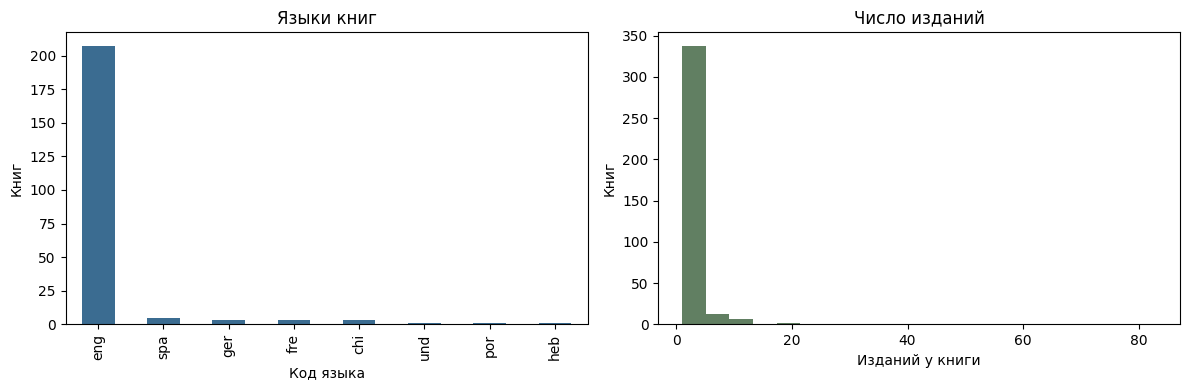

In [4]:
languages = pd.read_csv('book_languages.csv')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
languages['language'].value_counts().head(8).plot.bar(ax=axes[0], color='#3b6c91')
axes[0].set_title('Языки книг')
axes[0].set_xlabel('Код языка')
axes[0].set_ylabel('Книг')
data['edition_count'].plot.hist(bins=20, ax=axes[1], color='#617f62')
axes[1].set_title('Число изданий')
axes[1].set_xlabel('Изданий у книги')
axes[1].set_ylabel('Книг')
fig.tight_layout()
Path('figures').mkdir(exist_ok=True)
fig.savefig('figures/analysis.png', dpi=160)
plt.show()

## n8n

n8n получает три страницы Search API, преобразует поля и сохраняет CSV. Он собирает 30 книг без обогащения авторами.

In [5]:
nocode = pd.read_csv('nocode/nocode_result.csv')
joined = nocode.merge(data[['work_id', 'title', 'edition_count', 'url']], on='work_id', how='left', suffixes=('_n8n', '_python'), validate='one_to_one')
for field in ['title', 'edition_count', 'url']:
    assert joined[field + '_n8n'].eq(joined[field + '_python']).all()
assert len(nocode) >= 20
display(nocode.head())
print('Общие поля совпадают для всех', len(nocode), 'книг n8n')

,work_id,title,first_publish_year,edition_count,url
0,/works/OL10056472W,Bioinformatics Programming in Python,1991,4,https://openlibrary.org/works/OL10056472W
1,/works/OL1033722W,XML Processing with Python,2000,2,https://openlibrary.org/works/OL1033722W
2,/works/OL10538818W,The life of Python,1986,2,https://openlibrary.org/works/OL10538818W
3,/works/OL106747W,Python scripting for computational science,2004,2,https://openlibrary.org/works/OL106747W
4,/works/OL11791152W,Python for bioinformatics,2009,1,https://openlibrary.org/works/OL11791152W


Общие поля совпадают для всех 30 книг n8n


Часть книг не содержит языков или сведений об авторе. Эти поля оставлены пустыми.